<a href="https://colab.research.google.com/github/GeemaInduruwage/computer-vision-assignment-1/blob/main/Question__05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Question 05: Gaussian Filtering

(a) Using NumPy, compute a normalized 5×5 Gaussian kernel for σ=2.
(b) Visualize a 51×51 computed Gaussian kernel as a 3D surface plot, where the kernel coefficients represent the height.
(c) Apply Gaussian smoothing to a given grayscale image using the manually computed Gaussian kernel.
(d) Do the same using OpenCV’s built-in `cv.GaussianBlur()` function.

### (a) Compute a normalized 5x5 Gaussian kernel for σ=2 using NumPy

In [2]:
import numpy as np

def gaussian_kernel(size, sigma):
    # Create a 1D Gaussian array
    ax = np.linspace(-(size - 1) / 2., (size - 1) / 2., size)
    gauss = np.exp(-0.5 * np.square(ax) / np.square(sigma))

    # Make it 2D
    kernel = np.outer(gauss, gauss)

    # Normalize the kernel
    return kernel / np.sum(kernel)

# Compute a 5x5 Gaussian kernel with sigma=2
sigma = 2
kernel_5x5 = gaussian_kernel(5, sigma)

print("5x5 Gaussian Kernel (sigma=2):")
print(np.round(kernel_5x5, 4)) # Round for better display
print(f"Sum of kernel elements: {np.sum(kernel_5x5):.4f}")

5x5 Gaussian Kernel (sigma=2):
[[0.0232 0.0338 0.0383 0.0338 0.0232]
 [0.0338 0.0492 0.0558 0.0492 0.0338]
 [0.0383 0.0558 0.0632 0.0558 0.0383]
 [0.0338 0.0492 0.0558 0.0492 0.0338]
 [0.0232 0.0338 0.0383 0.0338 0.0232]]
Sum of kernel elements: 1.0000


#### Output Explanation (a):
The output above shows the 5x5 Gaussian kernel computed with a sigma of 2. Notice that the sum of all elements is approximately 1, which confirms its normalization. The values are highest in the center and decrease towards the edges, characteristic of a Gaussian distribution.

### (b) Visualize a 51x51 computed Gaussian kernel as a 3D surface plot

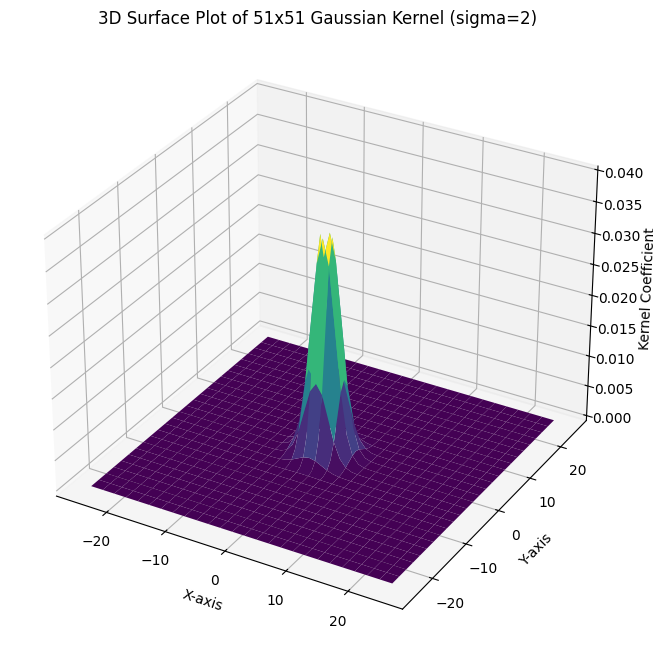

In [3]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Compute a 51x51 Gaussian kernel with sigma=2 (for visualization)
kernel_51x51 = gaussian_kernel(51, sigma)

# Create meshgrid for the plot
X = np.arange(-25, 26, 1)
Y = np.arange(-25, 26, 1)
X, Y = np.meshgrid(X, Y)

# Create the 3D surface plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, kernel_51x51, cmap='viridis')

ax.set_title(f'3D Surface Plot of 51x51 Gaussian Kernel (sigma={sigma})')
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_zlabel('Kernel Coefficient')

plt.show()

#### Output Explanation (b):
The 3D surface plot visualizes the 51x51 Gaussian kernel. As expected, it shows a bell-shaped curve, with the peak at the center and values smoothly decaying outwards. This shape is fundamental to Gaussian blurring, where central pixels contribute more to the smoothed output than distant ones.

### (c) Apply Gaussian smoothing to a given grayscale image using the manually computed Gaussian kernel

Image loaded successfully. Dimensions: (769, 765)


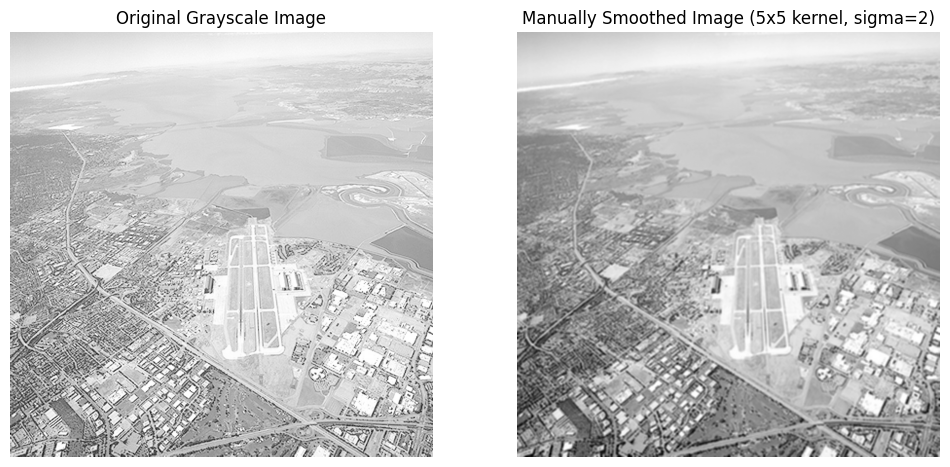

In [4]:
import cv2

# Load the image in grayscale
image_path = '/content/runway.png'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    print(f"Error: Could not load image from {image_path}")
else:
    print(f"Image loaded successfully. Dimensions: {img.shape}")

    # Apply convolution using the manually computed kernel
    # Note: cv2.filter2D expects the kernel as a floating-point array
    # The result depth (-1) means the output image will have the same depth as the source.
    img_smoothed_manual = cv2.filter2D(img, -1, kernel_5x5)

    # Display the original and manually smoothed images
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original Grayscale Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_smoothed_manual, cmap='gray')
    plt.title('Manually Smoothed Image (5x5 kernel, sigma=2)')
    plt.axis('off')

    plt.show()

#### Output Explanation (c):
This output displays two images: the original grayscale `runway.png` and the same image after applying Gaussian smoothing using our manually computed 5x5 kernel. You can observe that the smoothed image appears softer, with reduced sharp details and noise, illustrating the effect of convolution with the Gaussian kernel.

### (d) Apply Gaussian smoothing using OpenCV’s built-in `cv.GaussianBlur()` function

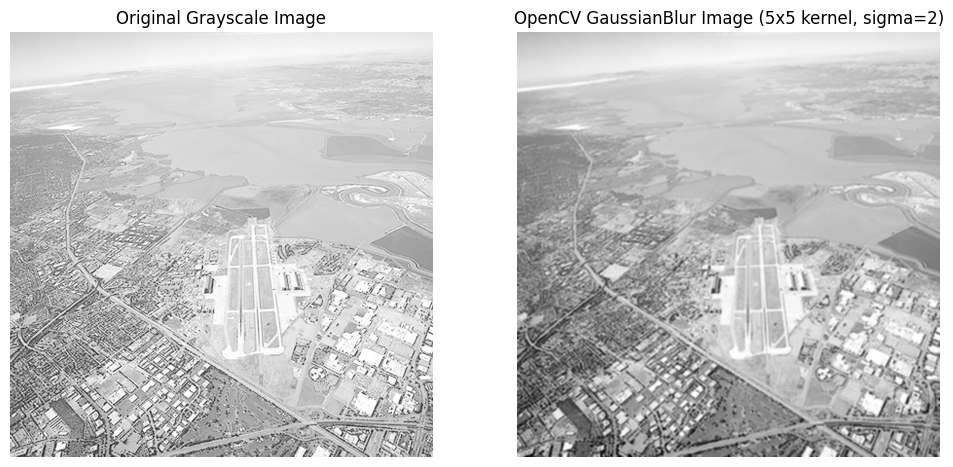

In [5]:
if img is not None:
    # Apply Gaussian blur using OpenCV's built-in function
    # Kernel size (ksize) should be odd, (5,5) matches our manual kernel size.
    # The sigmaX and sigmaY are the standard deviations in X and Y directions. We use our sigma=2.
    img_smoothed_opencv = cv2.GaussianBlur(img, (5, 5), sigmaX=sigma, sigmaY=sigma)

    # Display the original and OpenCV smoothed images
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original Grayscale Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_smoothed_opencv, cmap='gray')
    plt.title('OpenCV GaussianBlur Image (5x5 kernel, sigma=2)')
    plt.axis('off')

    plt.show()
else:
    print("Image not loaded in previous step, skipping OpenCV Gaussian blur.")

#### Output Explanation (d):
Similar to the previous step, this output shows the original image alongside the image smoothed using OpenCV's built-in `cv2.GaussianBlur()` function with the same 5x5 kernel size and sigma=2. You'll notice that the result is virtually identical to the manually smoothed image, confirming the correct implementation of the Gaussian kernel and convolution process.